In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

csv_path = '/content/drive/Shareddrives/depth_estimators/ECOCar Depth/rmse_results_v2.csv'
df = pd.read_csv(csv_path)

print(df.head())
print(f"\nTotal unseen segments: {len(df)}")

# Calibration formula used
print("\nCalibration:")

# Power function
print("  GT = 40.9741 * x^2.9651 + 9.1177")

print(f"  Calibration R² = 0.8825")

print(f"\nSeen   RMSE: 3.4979 m  (105 segments)")
print(f"Unseen RMSE: {df['mean_rmse'].mean():.4f} m  (245 segments)")

                                             segment   split  mean_rmse  \
0  segment-1331771191699435763_440_000_460_000_wi...  unseen   5.960299   
1  segment-9443948810903981522_6538_870_6558_870_...  unseen   3.136707   
2  segment-16204463896543764114_5340_000_5360_000...  unseen   7.261410   
3  segment-3126522626440597519_806_440_826_440_wi...  unseen   3.026916   
4  segment-13034900465317073842_1700_000_1720_000...  unseen   3.081244   

   n_frames  
0       198  
1       199  
2       198  
3       198  
4       198  

Total unseen segments: 245

Calibration:
  GT = 40.9741 * x^2.9651 + 9.1177
  Calibration R² = 0.8825

Seen   RMSE: 3.4979 m  (105 segments)
Unseen RMSE: 3.3965 m  (245 segments)


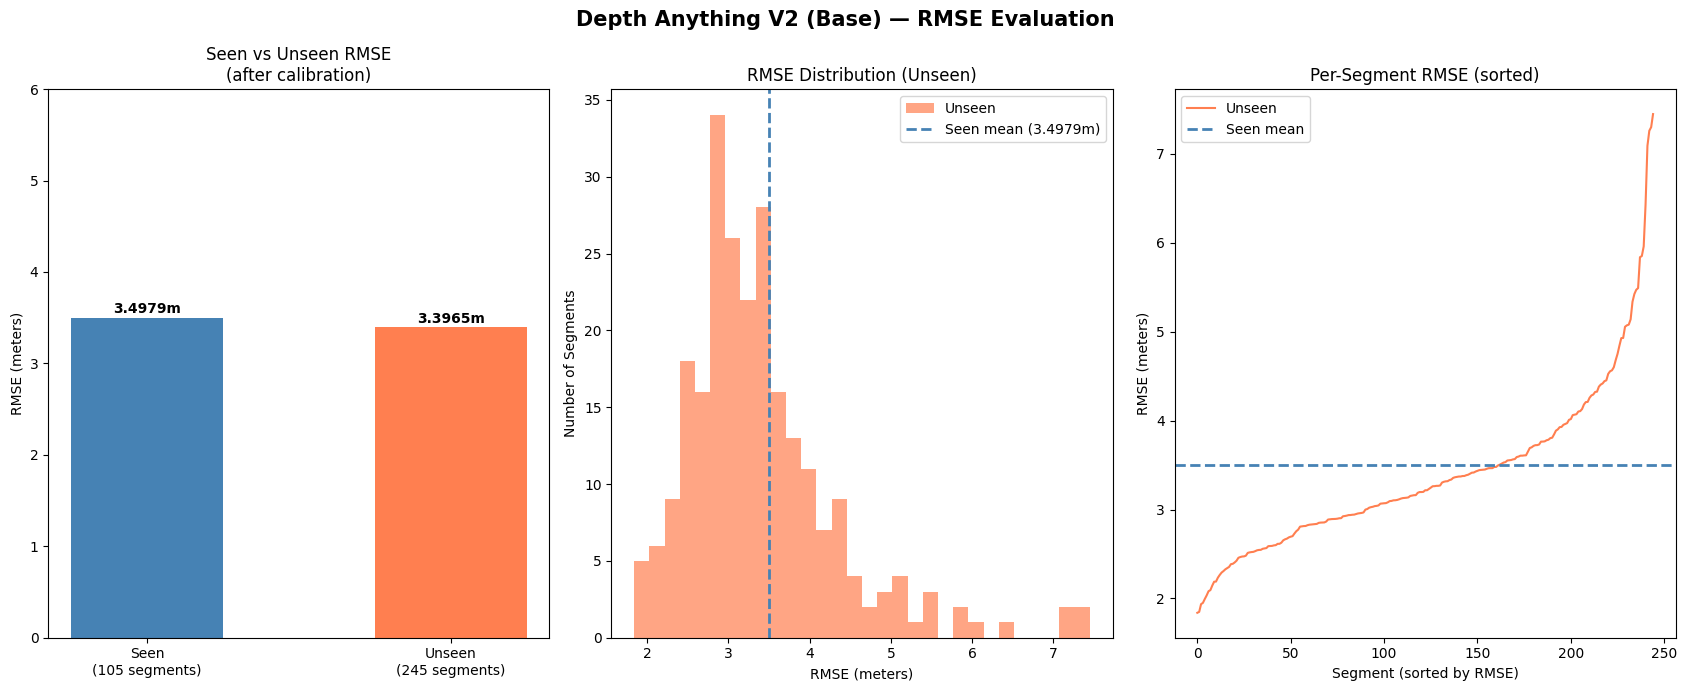

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 7))

fig.suptitle('Depth Anything V2 (Base) — RMSE Evaluation', fontsize=15, fontweight='bold')

# Bar chart
seen_rmse   = 3.4979

unseen_rmse = df['mean_rmse'].mean()
axes[0].bar(['Seen\n(105 segments)', 'Unseen\n(245 segments)'],
            [seen_rmse, unseen_rmse],
            color=['steelblue', 'coral'], width=0.5)

axes[0].set_ylabel('RMSE (meters)')
axes[0].set_title('Seen vs Unseen RMSE\n(after calibration)')


axes[0].set_ylim(0, 6)

for i, v in enumerate([seen_rmse, unseen_rmse]):
    axes[0].text(i, v + 0.05, f'{v:.4f}m', ha='center', fontweight='bold')

# Distribution
axes[1].hist(df['mean_rmse'], bins=30, alpha=0.7, color='coral', label='Unseen')
axes[1].axvline(seen_rmse, color='steelblue', linestyle='--', linewidth=2, label=f'Seen mean ({seen_rmse:.4f}m)')

axes[1].set_xlabel('RMSE (meters)')
axes[1].set_ylabel('Number of Segments')

axes[1].set_title('RMSE Distribution (Unseen)')
axes[1].legend()

# Segments sorted
unseen_vals = sorted(df['mean_rmse'].values)
axes[2].plot(unseen_vals, color='coral', label='Unseen')

axes[2].axhline(seen_rmse, color='steelblue', linestyle='--', linewidth=2, label=f'Seen mean')
axes[2].set_xlabel('Segment (sorted by RMSE)')

axes[2].set_ylabel('RMSE (meters)')
axes[2].set_title('Per-Segment RMSE (sorted)')

axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/Shareddrives/depth_estimators/ECOCar Depth/rmse_plot_v2.png', dpi=150, bbox_inches='tight')

plt.show()
